# OSM Tag Mapping

This notebook translates informative OpenStreetMap tags into the building classification taxonomy. Multiple tag signals are combined using source confidence and conflict-resolution rules to derive direct Level-1 and Level-2 building classifications.

**Input**
- Cleaned building data enriched with classification-relevant OSM tags.
- Tag-to-class mapping definitions for the building taxonomy.

**Output**
- Building-level Level-1 and Level-2 classifications derived from explicit OSM tag evidence.
- Classification provenance and resolved tag conflicts for subsequent classification stages.

In [137]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, sys
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (12, 5)})




ROOT_DIR = '/fast/home/o-olajuyigbe/osm_project'
DATA_DIR = os.path.join(ROOT_DIR, 'data')
SCRIPTS   = os.path.join(ROOT_DIR, 'scripts')

if SCRIPTS not in sys.path:
    sys.path.insert(0, SCRIPTS)


In [138]:
print("Loading Germany Data...")

# 1. Load Parquet files
df = gpd.read_parquet(os.path.join(DATA_DIR, 'interim', 'germany_buildings_cleaned_tags.parquet'))

print("Data loaded successfully!")

Loading Germany Data...
Data loaded successfully!


In [176]:
df[df['building'].isin(['conservatory'])][['id', 'building', 'amenity', 'building:use', 'name']].sample(10)

,id,building,amenity,building:use,name
38639052,1474254206,conservatory,None,None,None
37261197,1311817831,conservatory,None,None,None
37107451,1299926228,conservatory,None,None,None
37582332,1348757794,conservatory,None,None,None
37352757,1319060631,conservatory,None,None,None
36731336,1244623344,conservatory,None,None,None
37043277,1290172297,conservatory,None,None,None
38111289,1423608032,conservatory,None,None,None
36368466,1207091570,conservatory,None,None,None
30426484,797227229,conservatory,None,None,None


In [140]:
len(df[df['building'].isin(['water_works'])][['id', 'building', 'amenity', 'building:use']])

3

In [141]:
pd.set_option('display.max_rows', None)

In [142]:
import importlib
import tag_map
import shop_map

importlib.reload(tag_map)
importlib.reload(shop_map)

from tag_map import apply_tag_map
from shop_map import apply_shop_map

In [143]:
TOTAL = len(df)
print(f'Rows loaded  : {TOTAL:,}')
print(f'Columns      : {len(df.columns)}')

# Identify all tag columns
TAG_COLS = [c for c in df.columns if c.startswith('tags_')]
print(f'tags_* cols  : {len(TAG_COLS)}')
print()
print('Tag columns present:')
for c in sorted(TAG_COLS):
    n = df[c].notna().sum()
    print(f'  {c:<45} {n:>10,} non-null')

Rows loaded  : 38,802,372
Columns      : 85
tags_* cols  : 66

Tag columns present:
  tags_abandoned                                     8,722 non-null
  tags_abandoned:building                            1,212 non-null
  tags_aeroway                                       1,850 non-null
  tags_bench                                         9,474 non-null
  tags_bicycle_parking                               3,753 non-null
  tags_brand                                        44,179 non-null
  tags_brewery                                         702 non-null
  tags_building:type                                 2,994 non-null
  tags_building:type:de                              4,667 non-null
  tags_building:use:education                          675 non-null
  tags_building:use:office                           1,527 non-null
  tags_building:use:parking                         10,425 non-null
  tags_building:use:residential                     45,147 non-null
  tags_building:use:retail      

In [144]:
# ── strategy assignments ────────────────────────────────────
# direct_map = assign L1/L2 from a simple rule (no value lookup needed)
# apply_map  = run apply_building_map() on the raw value
# filter     = mark as filter structure; do not classify

STRATEGY = {
    # apply_map — value determines outcome
    'tags_proposed':            'apply_map',
    'tags_construction':        'apply_map',
    'tags_man_made':            'apply_map',
    'tags_power':               'apply_map', # related to substation
    'tags_leisure':             'apply_map',
    'tags_tourism':             'apply_map',
    'tags_historic':            'apply_map',
    'tags_building:type:de':    'apply_map',   # tags_building:type:de
    'tags_emergency':           'apply_map',
    'tags_aeroway':             'apply_map',
    'tags_railway':             'apply_map',
    'tags_public_transport':    'apply_map',
    'tags_building:type':       'apply_map',   # tags_building:type
    'tags_house':               'apply_map',
    'tags_government':          'apply_map',

    # direct_map — presence (or specific value) is enough
    'tags_community_centre':          ('civic',       'community'),
    'tags_diocese':                   ('civic',       'religious'),
    'tags_military':                  ('military',       None),
    'tags_healthcare':                ('civic',       'clinic'),     # # map all except hospital, pharmacy and rehabilitation (care_facility) to clinic
    'tags_social_facility':           ('civic',       'care_facility'),
    'tags_social_facility:for':       ('civic',       'care_facility'),
    'tags_building:use:retail':       ('commercial',  'retail'),     # if yes
    'tags_bunker_type':               ('military',    'bunker'),
    'tags_religion':                  ('civic',       'religious'),
    'tags_denomination':              ('civic',       'religious'), # if amenity =school, then school
    'tags_building:use:residential':  ('residential', None),   # if yes
    'tags_substation':                ('industrial',  'utilities'),
    'tags_cuisine':                   ('commercial',  'food_drink'),
    'tags_parish':                    ('civic',       'religious'),
    'tags_diet:vegetarian':           ('commercial',  'food_drink'),
    'tags_railway:signal_box':        ('transportation','maintenance'), # sinify it is signal box in tags
    'tags_castle_type':               ('civic',       'cultural'), # sinify it is castle
    'tags_healthcare:speciality':     ('civic',       'clinic'),
    'tags_diet:vegan':                ('commercial',  'food_drink'),
    'tags_second_hand':               ('commercial',  'retail'),
    'tags_building:use:office':       ('commercial',  'office'),     # if yes
    'tags_drive_through':             ('commercial',  None),
    'tags_delivery':                  ('commercial',  None), #  anything that has delivery should be commercial
    'tags_organic':                   ('commercial',  None), # could be retail or food_drink
    'tags_service:vehicle:car_repair':('commercial',  'retail'), # if yes, signify car repair
    'tags_education':                 ('civic',       'school'), # map all excep kindergarten, kindergarten should be mapped to kinder
    'tags_diet:halal':                ('commercial',  None), #  could be retail or food_drink
    'tags_museum':                    ('civic',       'cultural'), # signify museum
    'tags_building:use:education':    ('civic',       'school'),     # if yes
    'tags_townhall:type':             ('civic',       'government_office'), # signify townhall
    'tags_industrial':                'apply_map',         # subtype from value
    'tags_product':                   ('industrial',  'manufacturing'),

    # filter — mark is_filter_structure = True
    'tags_bicycle_parking':           'filter',
    'tags_disused':                   'apply_map', # is_abandoned = True if not no
    'tags_disused:building':          'apply_map', # is_abandoned = True
    'tags_abandoned':                 'filter', # make None and set  is_abandoned = True if not eual to no
    'tags_abandoned:building':        'apply_map', # is_abandoned = True
    'tags_demolished':                'filter', # is_abandoned = True
    'tags_ruins':                     'apply_map', # is_abandoned = True
    'tags_building:use:parking':      'filter', # if yes
    'tags_shelter_type':              'filter',
    'tags_bench':                     'filter', # all except no, signify bench
    'tags_parking':                   'filter', # all except multi-storey
    'tags_disused:shop':              'apply_map', # apply shop map, is_abandoned = True, if yes set to commercial.retail
    'tags_toilets:disposal':          'filter',
    'tags_disused:amenity':           'apply_map', # is_abandoned = True
    'tags_disused:tourism':           'apply_map', # is_abandoned = True
}

# Columns that indicate abandonment when non-null
ABANDONED_COLS = {
    'tags_disused', 'tags_disused:building', 'tags_abandoned:building',
    'tags_ruins', 'tags_demolished', 'tags_disused:shop',
    'tags_disused:amenity', 'tags_disused:tourism',
}


# Align strategy keys to actual column names in df
actual_strategy = {}
for raw_key, strat in STRATEGY.items():
    # try exact match first
    if raw_key in df.columns:
        actual_strategy[raw_key] = strat
    # try with tags_ prefix normalised
    elif raw_key in df.columns:
        actual_strategy[raw_key] = strat

# Report alignment
found = set(actual_strategy.keys())
tag_set = set(TAG_COLS)
in_strategy_not_df  = {k for k in STRATEGY if k not in tag_set and k not in tag_set}
in_df_not_strategy  = tag_set - found

print(f'Strategy entries aligned to actual columns : {len(actual_strategy)}')
print(f'Strategy keys not found in df              : {len(in_strategy_not_df)}')
if in_strategy_not_df:
    print(f'  {sorted(in_strategy_not_df)}')
print(f'Tag columns in df but not in strategy      : {len(in_df_not_strategy)}')
if in_df_not_strategy:
    print(f'  (these will be skipped during mapping)')
    for c in sorted(in_df_not_strategy):
        print(f'    {c}')


Strategy entries aligned to actual columns : 62
Strategy keys not found in df              : 0
Tag columns in df but not in strategy      : 4
  (these will be skipped during mapping)
    tags_brand
    tags_brewery
    tags_club
    tags_generator:source


In [145]:
# ── 1a: Coverage summary of all tag columns ──────────────────────────
coverage = (df[TAG_COLS].notna().sum() / TOTAL * 100).sort_values(ascending=False)
cov_df   = coverage.reset_index()
cov_df.columns = ['col', 'pct']
cov_df['n'] = (cov_df['pct'] / 100 * TOTAL).astype(int)
cov_df['strategy'] = cov_df['col'].map(
    lambda c: actual_strategy.get(c, 'not_in_strategy')
)

print('TAG COLUMN COVERAGE (sorted by n buildings)')
print(f'  {"Column":<45} {"N":>10} {"% filled":>9}  Strategy')
print('-' * 80)
for _, r in cov_df.iterrows():
    strat = r['strategy']
    strat_str = strat if isinstance(strat, str) else f'direct→{strat[0]}.{strat[1]}'
    print(f'  {r["col"]:<45} {r["n"]:>10,} {r["pct"]:>8.3f}%  {strat_str}')


TAG COLUMN COVERAGE (sorted by n buildings)
  Column                                                 N  % filled  Strategy
--------------------------------------------------------------------------------
  tags_house                                       137,240    0.354%  apply_map
  tags_man_made                                     82,801    0.213%  apply_map
  tags_power                                        78,139    0.201%  apply_map
  tags_religion                                     63,147    0.163%  direct→civic.religious
  tags_denomination                                 50,321    0.130%  direct→civic.religious
  tags_historic                                     45,434    0.117%  apply_map
  tags_building:use:residential                     45,147    0.116%  direct→residential.None
  tags_brand                                        44,179    0.114%  not_in_strategy
  tags_tourism                                      41,145    0.106%  apply_map
  tags_substation             

In [146]:
df[(df['tags_brewery'].notna()) &
    (df['building'] == 'industrial')][
    ['id', 'building', 'amenity', 'shop', 'building:use','tags_brewery']
].head(10)

,id,building,amenity,shop,building:use,tags_brewery
1234736,77609658,industrial,None,None,None,Friesisches Brauhaus zu Jever
8866650,215570072,industrial,None,None,None,Pfaffen
10424540,237563840,industrial,None,None,None,Schwarzbräu


In [147]:
df[df['tags_club'].notna()][
    ['id', 'building', 'amenity', 'shop', 'building:use','tags_club']
].sample(10)

,id,building,amenity,shop,building:use,tags_club
5070688,150921975,yes,None,None,None,allotments
36702,26031144,yes,None,None,None,allotments
3007532,113784437,yes,None,None,None,yes
14484513,287104546,yes,None,None,None,sport
14273194,284474700,yes,None,None,None,sport
10495128,238419127,yes,community_centre,None,None,sport
1005124,60980291,yes,None,None,None,yes
9349911,222476065,warehouse,None,None,None,rowing
31087357,842341190,yes,None,None,None,sport
23473165,446937220,public,None,None,None,sport


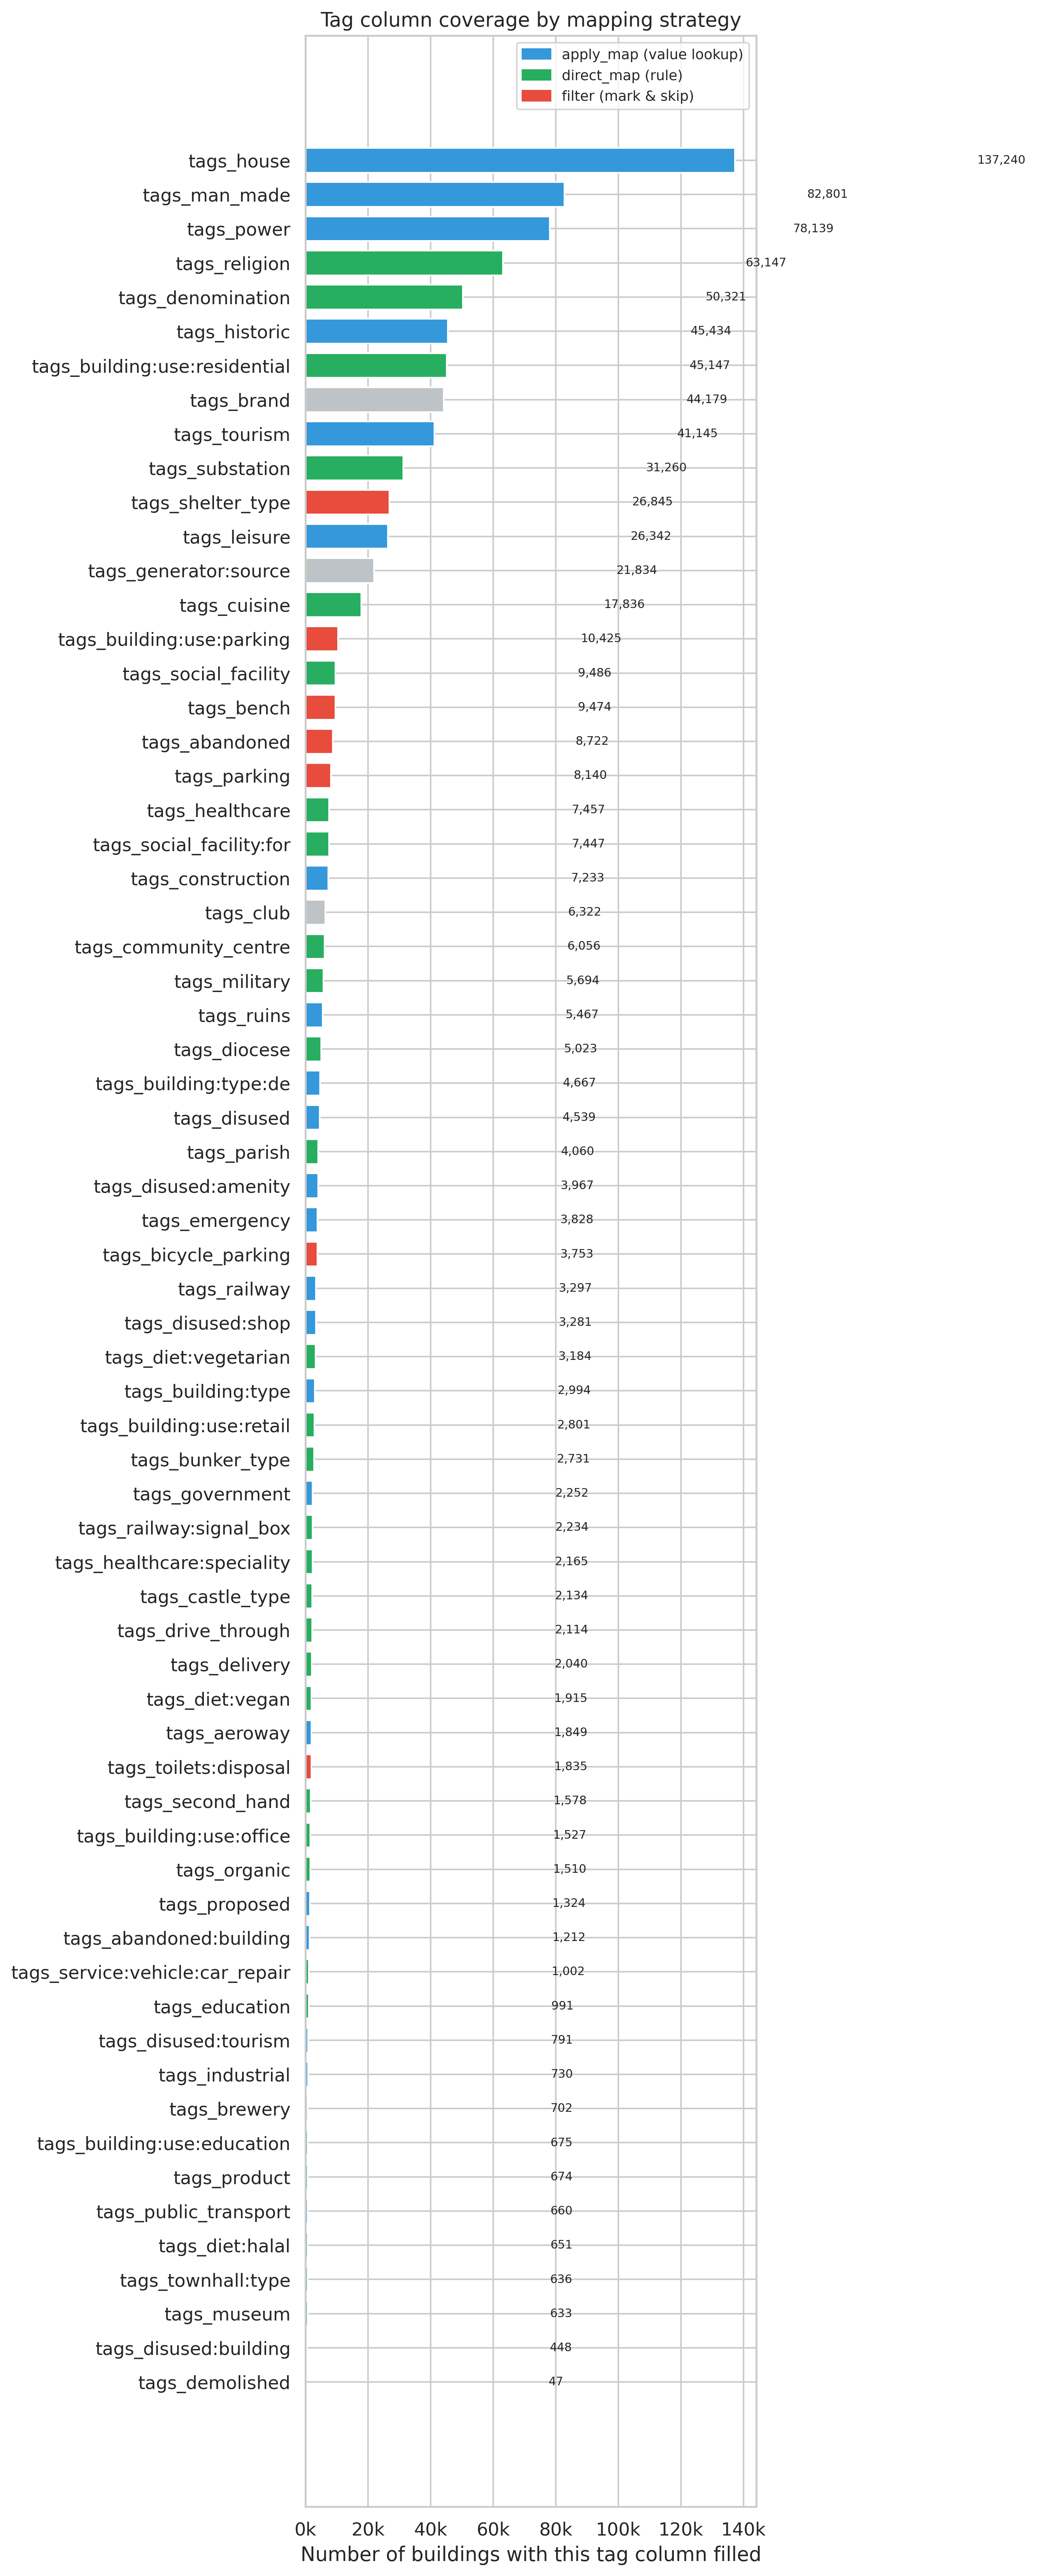

In [148]:
# ── Plot: tag column coverage by strategy ────────────────────────────
import matplotlib.ticker as ticker

STRAT_COLOR = {'filter':'#e74c3c', 'apply_map':'#3498db',
               'direct_map_tuple':'#27ae60', 'not_in_strategy':'#bdc3c7'}

def strat_color(s):
    if s == 'filter': return '#e74c3c'
    if s == 'apply_map': return '#3498db'
    if isinstance(s, tuple): return '#27ae60'
    return '#bdc3c7'

cov_plot = cov_df[cov_df['n'] > 0].sort_values('n')
colors = [strat_color(actual_strategy.get(r['col'], 'x')) for _, r in cov_plot.iterrows()]

fig, ax = plt.subplots(figsize=(12, max(6, len(cov_plot)*0.35)), dpi=300)
bars = ax.barh(cov_plot['col'], cov_plot['n'], color=colors, edgecolor='white', height=0.72)
for bar, val in zip(bars, cov_plot['n']):
    ax.text(bar.get_width() + TOTAL*0.002, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=7.5)
patches = [mpatches.Patch(color='#3498db', label='apply_map (value lookup)'),
           mpatches.Patch(color='#27ae60', label='direct_map (rule)'),
           mpatches.Patch(color='#e74c3c', label='filter (mark & skip)')]
ax.legend(handles=patches, fontsize=9)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k' if x < 1e6 else f'{x/1e6:.1f}M'))
ax.set_xlabel('Number of buildings with this tag column filled')
ax.set_title('Tag column coverage by mapping strategy')
plt.tight_layout(); plt.show()


### Apply Map Column

In [149]:
# Helper: top-N value distribution for a column
def show_col_dist(col, top_n=25, df=df):
    if col not in df.columns:
        print(f'{col}: not found'); return
    vc = df[col].value_counts(dropna=True).head(top_n)
    if vc.empty:
        print(f'{col}: all null'); return
    total_col = df[col].notna().sum()
    print(f'\n── {col} ── ({total_col:,} non-null, {df[col].nunique()} unique values)')
    for val, cnt in vc.items():
        print(f'  {str(val):<45} {cnt:>8,}  ({cnt/total_col*100:.1f}%)')

# Run for all apply_map columns that have data
apply_cols = [c for c, s in actual_strategy.items() if s =='apply_map']
for col in sorted(apply_cols):
    if df[col].notna().sum() > 0:
        show_col_dist(col)



── tags_abandoned:building ── (1,212 non-null, 61 unique values)
  yes                                                585  (48.3%)
  residential                                         84  (6.9%)
  industrial                                          84  (6.9%)
  bunker                                              55  (4.5%)
  hangar                                              47  (3.9%)
  house                                               45  (3.7%)
  apartments                                          32  (2.6%)
  train_station                                       30  (2.5%)
  hospital                                            26  (2.1%)
  farm                                                18  (1.5%)
  service                                             15  (1.2%)
  farm_auxiliary                                      15  (1.2%)
  garages                                             13  (1.1%)
  barn                                                13  (1.1%)
  warehouse            

In [150]:
# Count how many tag columns (non-null, non-filter) does a building have
# Include filter cols that have special value-based exceptions
FILTER_WITH_EXCEPTIONS = {'tags_parking', 'tags_bench', 'tags_building:use:parking'}

non_filter_cols = [
    c for c in STRATEGY
    if (STRATEGY[c] != 'filter' or c in FILTER_WITH_EXCEPTIONS)
    and c in df.columns
]

signal_count = df[non_filter_cols].notna().sum(axis=1)

print('NUMBER OF TAG COLUMNS PER BUILDING:')
print(f'  (considering {len(non_filter_cols)} non-filter tag columns)')
sc_counts = signal_count.value_counts().sort_index()
for n_sig, cnt in sc_counts.items():
    bar = '█' * min(60, int(cnt / TOTAL * 200))
    print(f'  {n_sig:>2} tags : {cnt:>10,}  ({cnt/TOTAL*100:.2f}%)  {bar}')
print()
print(f'Buildings with >= 2 simultaneous tags: '
      f'{(signal_count >= 2).sum():,}  ({(signal_count >= 2).sum()/TOTAL*100:.2f}%)')
print(f'Buildings with >= 3 simultaneous tags: '
      f'{(signal_count >= 3).sum():,}  ({(signal_count >= 3).sum()/TOTAL*100:.2f}%)')


NUMBER OF TAG COLUMNS PER BUILDING:
  (considering 57 non-filter tag columns)
   0 tags : 38,174,231  (98.38%)  ████████████████████████████████████████████████████████████
   1 tags :    505,777  (1.30%)  ██
   2 tags :    106,946  (0.28%)  
   3 tags :     10,307  (0.03%)  
   4 tags :      4,436  (0.01%)  
   5 tags :        569  (0.00%)  
   6 tags :        105  (0.00%)  
   7 tags :          1  (0.00%)  

Buildings with >= 2 simultaneous tags: 122,364  (0.32%)
Buildings with >= 3 simultaneous tags: 15,418  (0.04%)


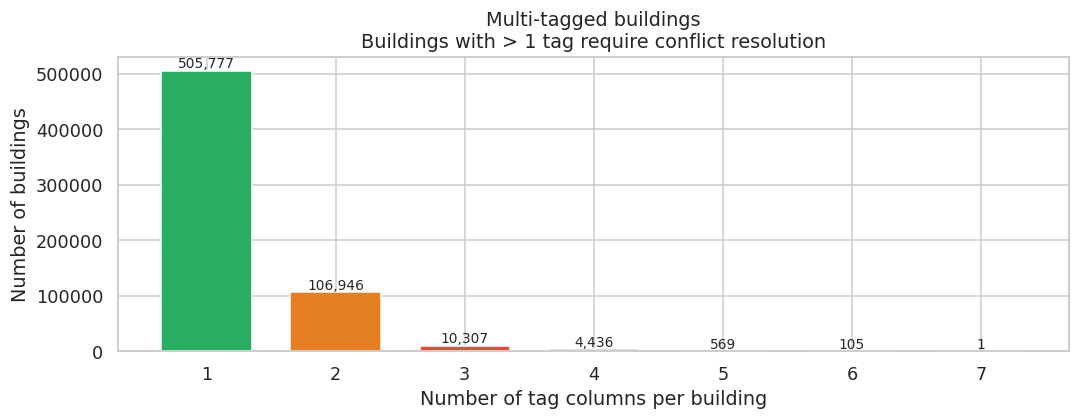

In [151]:
# ── Plot: signal count distribution ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
sc_plot = sc_counts[sc_counts.index > 0]  # exclude 0-signal buildings
ax.bar(sc_plot.index.astype(str), sc_plot.values,
       color=['#27ae60','#e67e22','#e74c3c','#9b59b6','#3498db'][:len(sc_plot)],
       edgecolor='white', width=0.7)
for x, y in zip(sc_plot.index.astype(str), sc_plot.values):
    ax.text(x, y + max(sc_plot.values)*0.01, f'{y:,}', ha='center', fontsize=9)
ax.set_xlabel('Number of tag columns per building')
ax.set_ylabel('Number of buildings')
ax.set_title('Multi-tagged buildings\nBuildings with > 1 tag require conflict resolution')
plt.tight_layout(); plt.show()


In [152]:
# 1. Filter the dataframe for buildings with EXACTLY 2 signals
# (Change == 2 to >= 2 if you want to include 3+ tags as well)
two_tags_df = df[signal_count >= 2]

print(f"Total buildings with exactly 2 tags: {len(two_tags_df):,}\n")
print("SAMPLE OF 10 BUILDINGS AND THEIR SPECIFIC TAGS:")
print("-" * 60)

# 2. Take a random sample so you get a good variety of combinations
sample_size = min(20, len(two_tags_df))
sample_df = two_tags_df.sample(sample_size)

# 3. Iterate through the sample and print only the non-null columns
for idx, row in sample_df.iterrows():
    # Grab only the non_filter_cols for this row, and drop the NaNs
    active_tags = row[non_filter_cols].dropna()
    
    # Print the building ID/Index and its actual tags
    print(f"Building Index/ID: {idx}")
    for col_name, val in active_tags.items():
        print(f"  • {col_name}: '{val}'")
    print()

Total buildings with exactly 2 tags: 122,364

SAMPLE OF 10 BUILDINGS AND THEIR SPECIFIC TAGS:
------------------------------------------------------------
Building Index/ID: 15276252
  • tags_power: 'substation'
  • tags_substation: 'minor_distribution'

Building Index/ID: 10906321
  • tags_cuisine: 'pizza'
  • tags_drive_through: 'no'
  • tags_delivery: 'yes'

Building Index/ID: 4401312
  • tags_religion: 'christian'
  • tags_denomination: 'catholic'

Building Index/ID: 16266241
  • tags_diet:vegetarian: 'yes'
  • tags_diet:vegan: 'no'

Building Index/ID: 16413650
  • tags_religion: 'christian'
  • tags_denomination: 'catholic'

Building Index/ID: 35879254
  • tags_power: 'substation'
  • tags_substation: 'minor_distribution'

Building Index/ID: 34367701
  • tags_religion: 'christian'
  • tags_denomination: 'protestant'

Building Index/ID: 96902
  • tags_religion: 'christian'
  • tags_denomination: 'roman_catholic'

Building Index/ID: 31703422
  • tags_power: 'substation'
  • tags_sub

In [153]:

# 1. Get the buildings with >= 2 signals
multi_df = df[signal_count >= 2][non_filter_cols]

# 2. Convert to a boolean matrix (1 if tag is present, 0 if empty)
bool_df = multi_df.notna().astype(int)

# 3. Matrix multiplication calculates the co-occurrence of every column instantly
print("Calculating co-occurrence matrix...")
co_occ_matrix = bool_df.T.dot(bool_df)

# 4. Mask the matrix to avoid counting the diagonal (A co-occurring with A) 
# and the lower triangle (avoiding duplicate A-B and B-A pairs)
mask = np.triu(np.ones(co_occ_matrix.shape), k=1).astype(bool)
pairs = co_occ_matrix.where(mask).stack()

# 5. Sort to find the most frequent pairs
top_pairs = pairs.sort_values(ascending=False).head(50)

print("\nTOP 50 MOST FREQUENTLY CO-OCCURRING TAG PAIRS:")
print("-" * 85)
print(f"{'Tag A':<35} | {'Tag B':<35} | {'Co-occurrences':>12}")
print("-" * 85)

for (tag_a, tag_b), count in top_pairs.items():
    if count > 0:
        print(f"{tag_a:<35} | {tag_b:<35} | {int(count):>12,}")

Calculating co-occurrence matrix...

TOP 50 MOST FREQUENTLY CO-OCCURRING TAG PAIRS:
-------------------------------------------------------------------------------------
Tag A                               | Tag B                               | Co-occurrences
-------------------------------------------------------------------------------------
tags_religion                       | tags_denomination                   |       49,723
tags_power                          | tags_substation                     |       30,357
tags_social_facility                | tags_social_facility:for            |        6,977
tags_diocese                        | tags_religion                       |        5,011
tags_diocese                        | tags_denomination                   |        4,998
tags_denomination                   | tags_parish                         |        4,046
tags_religion                       | tags_parish                         |        4,045
tags_building:type:de         

Most of the buildings with multiple tags are in the same category, so they are not conflicting. 
- tags_ religion, tags_denomination, tags_diocese, tags_parish all belong to civic.religious
- tags_power, tags_generator:source, tags_substation, 

In [154]:
print("Evaluating exact L1 and L2 categories for conflicts...\n")

detailed_conflicts = []

# Using the multi_df from your previous step (buildings with >= 2 tags)
for idx, row in multi_df.iterrows():
    # Store unique combinations of (L1, L2)
    mapped_categories = set()
    evidence = []
    
    for col in non_filter_cols:
        val = row[col]
        if pd.notna(val) and val != '':
            strat = actual_strategy.get(col)
            l1, l2 = None, None
            
            # Extract L1 and L2 based on the strategy
            if isinstance(strat, tuple):
                l1, l2 = strat[0], strat[1]
            elif strat == 'apply_map':
                res = apply_tag_map(val)
                if res and res[0]: 
                    l1, l2 = res[0], res[1]
            
            if l1 and l1 != 'filter':
                # Handle cases where L2 might be missing/None
                l2_str = l2 if pd.notna(l2) and l2 else "unspecified"
                mapped_categories.add((l1, l2_str))
                evidence.append(f"{col}='{val}' → {l1}({l2_str})")
                
    # If the building resolves to more than one distinct (L1, L2) pair
    if len(mapped_categories) > 1:
        # Check if L1s are different, or just L2s
        l1s = set([cat[0] for cat in mapped_categories])
        c_type = "L1 Conflict (Major)" if len(l1s) > 1 else "L2 Conflict (Minor)"
        
        # Format the clash nicely: e.g., "commercial(retail) vs residential(apartments)"
        clash_str = " vs ".join(sorted([f"{c[0]}({c[1]})" for c in mapped_categories]))
        
        detailed_conflicts.append({
            'building_idx': idx,
            'conflict_type': c_type,
            'clash': clash_str,
            'evidence': " | ".join(evidence)
        })

df_conflicts = pd.DataFrame(detailed_conflicts)

if not df_conflicts.empty:
    print("=====================================================================")
    print(f"MAJOR CONFLICTS (Different L1 Categories): {(df_conflicts['conflict_type'] == 'L1 Conflict (Major)').sum():,}")
    print("=====================================================================")
    print(df_conflicts[df_conflicts['conflict_type'] == 'L1 Conflict (Major)']['clash'].value_counts().head(10))
    
    print("\n=====================================================================")
    print(f"MINOR CONFLICTS (Same L1, Different L2 Subcategories): {(df_conflicts['conflict_type'] == 'L2 Conflict (Minor)').sum():,}")
    print("=====================================================================")
    print(df_conflicts[df_conflicts['conflict_type'] == 'L2 Conflict (Minor)']['clash'].value_counts().head(10))
    
    print("\nSAMPLE OF 5 ACTUAL BUILDINGS CAUSING MAJOR CONFLICTS:")
    with pd.option_context('display.max_colwidth', None):
        display(df_conflicts[df_conflicts['conflict_type'] == 'L1 Conflict (Major)'][['clash', 'evidence']].sample(min(25, len(df_conflicts))))
else:
    print("No conflicts found!")

Evaluating exact L1 and L2 categories for conflicts...

MAJOR CONFLICTS (Different L1 Categories): 2,698
clash
commercial(retail) vs residential(unspecified)                          1670
commercial(office) vs residential(unspecified)                           156
civic(clinic) vs commercial(unspecified)                                 144
commercial(office) vs commercial(retail) vs residential(unspecified)      78
civic(cultural) vs industrial(utilities)                                  56
civic(cultural) vs commercial(accommodation)                              46
civic(cultural) vs residential(SFH)                                       25
commercial(accommodation) vs residential(SFH)                             22
civic(recreation) vs commercial(food_drink)                               21
civic(cultural) vs industrial(manufacturing)                              19
Name: count, dtype: int64

MINOR CONFLICTS (Same L1, Different L2 Subcategories): 12,238
clash
commercial(food_drink) v

,clash,evidence
5970,civic(cultural) vs industrial(utilities),tags_tourism='artwork' → civic(cultural) | tags_substation='compression' → industrial(utilities)
8365,civic(cultural) vs commercial(accommodation),tags_tourism='hotel' → commercial(accommodation) | tags_historic='castle' → civic(cultural) | tags_castle_type='manor' → civic(cultural)
6141,commercial(retail) vs residential(unspecified),tags_building:use:retail='yes' → commercial(retail) | tags_building:use:residential='yes' → residential(unspecified)
8047,commercial(retail) vs residential(unspecified),tags_building:use:retail='yes' → commercial(retail) | tags_building:use:residential='yes' → residential(unspecified)
130,civic(clinic) vs commercial(unspecified),tags_healthcare='pharmacy' → civic(clinic) | tags_drive_through='no' → commercial(unspecified)
6646,commercial(retail) vs residential(unspecified),tags_building:use:retail='yes' → commercial(retail) | tags_building:use:residential='yes' → residential(unspecified)
2839,commercial(retail) vs residential(unspecified),tags_building:use:retail='yes' → commercial(retail) | tags_building:use:residential='yes' → residential(unspecified)
7231,commercial(retail) vs residential(unspecified),tags_building:use:retail='yes' → commercial(retail) | tags_building:use:residential='yes' → residential(unspecified)
8456,civic(cultural) vs industrial(utilities),tags_power='substation' → industrial(utilities) | tags_tourism='artwork' → civic(cultural)
11062,commercial(office) vs residential(unspecified),tags_building:use:residential='yes' → residential(unspecified) | tags_building:use:office='yes' → commercial(office)


In [155]:
# 1. Filter to buildings with >= 2 signals
multi_mask = signal_count >= 2.
multi_df   = df[multi_mask].copy() # Keep all columns so we have OSM IDs if needed

print(f'Evaluating {len(multi_df):,} multi-signal buildings for exact conflicts...\n')

actual_conflicts = []

# 2. Iterate through multi-signal buildings
for idx, row in multi_df.iterrows():
    building_l1s = set()
    tag_details = []
    
    # Check every non-filter column for this specific building
    for col in non_filter_cols:
        val = row[col]
        if pd.notna(val) and val != '':
            
            # Find the exact L1 for this specific value
            strat = actual_strategy.get(col)
            l1 = None
            
            if isinstance(strat, tuple):
                l1 = strat[0]  # Direct map
            elif strat == 'apply_map':
                res = apply_tag_map(val) # Evaluate the exact value
                if res and res[0]: 
                    l1 = res[0]
            
            # If it yielded a valid L1, record it
            if l1 and l1 != 'filter':
                building_l1s.add(l1)
                tag_details.append(f"{col}='{val}' → {l1}")
                
    # 3. If this single building resolves to MORE THAN ONE distinct L1 category, it's a true conflict with the building id

    if len(building_l1s) > 1:
        actual_conflicts.append({
            'building_idx': idx,
            'conflict_l1s': " vs ".join(sorted(building_l1s)),
            'tag_evidence': " | ".join(tag_details)
        })

# 4. Convert results to a DataFrame for easy viewing
conflicts_df = pd.DataFrame(actual_conflicts)

print(f"Found {len(conflicts_df):,} buildings with GENUINE L1 conflicts.")
print("-" * 80)

if not conflicts_df.empty:
    # Show how many times each specific L1 clash happens
    print("\nMOST COMMON EXACT L1 CLASHES:")
    print(conflicts_df['conflict_l1s'].value_counts().head(10))
    
    print("\nSAMPLE OF 10 ACTUAL CONFLICTING BUILDINGS:")
    # Set pandas display options temporarily to show the full text
    with pd.option_context('display.max_colwidth', None):
        display(conflicts_df[['conflict_l1s', 'tag_evidence']].sample(min(10, len(conflicts_df))))

Evaluating 122,364 multi-signal buildings for exact conflicts...

Found 2,698 buildings with GENUINE L1 conflicts.
--------------------------------------------------------------------------------

MOST COMMON EXACT L1 CLASHES:
conflict_l1s
commercial vs residential                       2001
civic vs commercial                              323
civic vs residential                             120
civic vs industrial                               92
commercial vs industrial                          36
military vs transportation                        22
civic vs military                                 22
civic vs transportation                           18
commercial vs residential vs semi_commercial      14
commercial vs transportation                       9
Name: count, dtype: int64

SAMPLE OF 10 ACTUAL CONFLICTING BUILDINGS:


,conflict_l1s,tag_evidence
1943,commercial vs residential,tags_building:use:retail='yes' → commercial | tags_building:use:residential='yes' → residential
840,civic vs residential,tags_tourism='chalet' → residential | tags_disused:amenity='fire_station' → civic
2132,commercial vs residential,tags_building:use:retail='yes' → commercial | tags_building:use:residential='yes' → residential
659,commercial vs residential,tags_building:use:retail='yes' → commercial | tags_building:use:residential='yes' → residential
1215,commercial vs residential,tags_building:use:retail='yes' → commercial | tags_building:use:residential='yes' → residential
2288,civic vs commercial,tags_tourism='hotel' → commercial | tags_historic='castle' → civic | tags_castle_type='stately' → civic
2016,commercial vs residential,tags_building:use:retail='yes' → commercial | tags_building:use:residential='yes' → residential
2157,commercial vs residential,tags_building:use:retail='yes' → commercial | tags_building:use:residential='yes' → residential
500,commercial vs residential,tags_building:use:retail='yes' → commercial | tags_building:use:residential='yes' → residential
2197,commercial vs residential,tags_building:use:retail='yes' → commercial | tags_building:use:residential='yes' → residential


we can directly identify ~2000 semi_commercial buildings, als conflicting shows mixed use buildings

### Apply Map

In [156]:
# ── Source confidence (higher = more trusted) ─────────────────────────

CONFIDENCE = {
    'tags_building:use:retail':      10,
    'tags_building:use:office':      10,
    'tags_building:use:residential': 10,
    'tags_education':                10,
    'tags_service:vehicle:car_repair':10,
    'tags_castle:type':              10,
    'tags_townhall:type':            10,
    'tags_bunker_type':              10,
    'tags_museum':                   10,
    'tags_railway:signal_box':        9,
    'tags_building:type':             9,
    'tags_building:type:de':          9,
    'tags_healthcare:speciality':     8,
    'tags_house':                     9,
    'tags_military':                  9,
    'tags_second_hand':               9,
    'tags_industrial':                9,
    'tags_building:use:education':    9,
    'tags_social_facility:for':       8,
    'tags_public_transport':          8,
    'tags_social_facility':           8,
    'tags_leisure':                   8,
    'tags_product':                   8,
    'tags_aeroway':                   8,
    'tags_man_made':                  8,
    'tags_healthcare':                9,
    'tags_community_centre':          6,
    'tags_government':                7,
    'tags_tourism':                   7,
    'tags_club':                      6,       
    'tags_delivery':                  7,
    'tags_drive_through':             7,
    'tags_historic':                  5,
    'tags_proposed':                  5,
    'tags_construction':              5,
    'tags_railway':                   4,
    'tags_religion':                  2,
    'tags_denomination':              2,
    'tags_diocese':                   2,
    'tags_parish':                    2,
    'tags_organic':                   1,
    'tags_substation':                7,
    'tags_power':                     7,    
    'tags_generator:source':          7,    
}

# tas with same conf, combine, eg semi_commercial, res_shool
DEFAULT_CONFIDENCE = 3


#### Step 1 — `extract_candidates()`

For each building, collect **every classification signal** from every
non-filter tag column.  
Output: list of `{l1, l2, source, tag, confidence, is_abandoned}` dicts.

In [157]:
# ── Override raw tags for cleaner output ──────────────────────────
TAG_USED_OVERRIDES = {
    'tags_bunker_type': 'bunker',
    'tags_castle_type': 'castle',
    'tags_social_facility:for': 'social_facility',
    'tags_museum': 'museum',
    'tags_townhall:type': 'townhall',
    'tags_railway:signal_box': 'signal_box',
}

def extract_candidates(row):
    """
    Given a single building row, return a list of candidate dicts.
    Each dict: {l1, l2, source, tag, confidence, is_abandoned}
    """
    candidates = []
    is_abandoned = False

    for col in non_filter_cols:
        val = row.get(col)
        if pd.isna(val) or val == '' or val is None:
            continue
        val_str = str(val).strip().lower()
        strat   = STRATEGY.get(col)
        conf    = CONFIDENCE.get(col, DEFAULT_CONFIDENCE)
        # ── Mark abandonment ──────────────────────────────────────────
        if col in ABANDONED_COLS:
            if val_str != 'no':
                is_abandoned = True          # set flag; still try to classify

        l1, l2 = None, None

        # ── direct_map ───────────────────────────────────────────────
        if isinstance(strat, tuple):
            l1, l2 = strat[0], strat[1]

            # Special overrides for direct_map cols whose *value* matters
            if col == 'tags_healthcare':
                if val_str in ('hospital',):
                    l2 = 'hospital'
                elif val_str in ('pharmacy',):
                    l1, l2 = 'commercial', 'retail'
                elif val_str in ('rehabilitation', 'nursing_home'):
                    l2 = 'care_facility'

            if col == 'tags_education':
                if val_str in ('kindergarten', 'pre-school', 'preschool'):
                    l2 = 'kindergarten'
                elif val_str in ('college', 'university'):
                    l2 = 'higher_ed'

            
            if col in ['tags_building:use:retail', 'tags_building:use:residential', 'tags_building:use:office', 
                       'tags_service:vehicle:car_repair', 'tags_building:use:education']:  
                if val_str != 'yes':
                    continue  # skip if not explicitly yes        

        # ── apply_map ─────────────────────────────────────────────────
        elif strat == 'apply_map':
            if col == 'tags_disused:shop':
                if val_str == 'no':
                    l1, l2 = 'commercial', 'retail'
                else:
                    result = apply_shop_map(val_str)
                    if result and len(result) >= 2:
                        l1, l2 = result[0], result[1]
            elif col == 'tags_industrial':
                mapped_tuple = apply_tag_map(val_str)
                # Only overwrite if apply_tag_map found a valid L1!
                if mapped_tuple and mapped_tuple[0] == 'industrial':
                    l1, l2 = mapped_tuple[0], mapped_tuple[1]
                else:
                    # Safe fallback for unknown industrial tags
                    l1, l2 = 'industrial', None
                    
            else:
                result = apply_tag_map(val_str)
                if result and len(result) >= 2:
                    l1, l2 = result[0], result[1]

        # ── skip filter ───────────────────────────────────────────────
        elif strat == 'filter':
            if col == 'tags_parking' and val_str == 'multi-storey':
                l1, l2 = 'transportation', 'parking'
            elif col == 'tags_bench' and val_str == 'no':
                continue
            elif col == 'tags_building:use:parking' and val_str != 'yes':
                continue
            else:
                l1, l2 = 'filter', None
        
        if l1 is None: 
            continue

        # Look up if this column has a hardcoded override, otherwise use val_str
        display_tag = TAG_USED_OVERRIDES.get(col, val_str)

        candidates.append({
            'l1':         l1,
            'l2':         l2,
            'source':     col,
            'tag':        display_tag,  
            'confidence': conf,
            'is_abandoned': is_abandoned,
        })

    return candidates, is_abandoned

# quick sanity test
row0 = df.iloc[11019]
cands, aband = extract_candidates(row0)
print(f'Sample row 11019 — {len(cands)} candidate(s), abandoned={aband}')
for c in cands:
    print(f'  {c["source"]:40s}  {c["l1"]:15s} / {str(c["l2"]):20s}  conf={c["confidence"]}')


Sample row 11019 — 1 candidate(s), abandoned=False
  tags_industrial                           industrial      / None                  conf=9


#### Step 2 — `resolve_candidates()`

##### Conflict-resolution logic (in order)

1. **No candidates** → unclassified  
2. **One candidate** → use it
2. **All same L1 + L2** → use it  
3. **Same L1, different L2** (minor):  
   - Drop `None` / `unspecified` if a specific L2 exists  
   - if commercial combine using underscore
   - Otherwise use highest-confidence source  
4. **residential + commercial/civic** → `semi_commercial`  
6. **Different L1** (major) →  confidence score.

   Tie break by priority ladder:  
   `military > industrial > civic > commercial > residential > agricultural > filter`

In [ ]:
# ── L1 priority (lower index = higher priority) ───────────────────────
L1_PRIORITY: list[str] = [
   'military', 'industrial',  'civic', 'transportation', 'semi_commercial', 'commercial', 
   'residential', 'agricultural', 'filter'
]

def l1_rank(l1):
    try:
        return L1_PRIORITY.index(l1)
    except ValueError:
        return 99
    
def resolve_l2(candidates):
    """Resolve L2: merge if all commercial, else pick highest-confidence.
    1. Drop None L2s if any concrete L2 exists
    2. If all concrete L2s are the same → return it directly (no conflict)
    3. If different → pick highest confidence winner
    4. If confidence tie → return None (genuine ambiguity)"""
    # Remove None / 'unspecified' if a concrete L2 exists
    concrete = [c for c in candidates if c['l2'] is not None]
    
    if not concrete:
        return None

    unique_l2s = set(c['l2'] for c in concrete)

    # Step 2: all agree → no conflict, return immediately
    if len(unique_l2s) == 1:
        return concrete[0]['l2']

    # Different L2s → highest confidence wins
    max_conf = max(c['confidence'] for c in concrete)
    top = [c for c in concrete if c['confidence'] == max_conf]

    # Genuine tie → ambiguity
    if len(top) > 1:
        return None

    return top[0]['l2']

def make_semi_commercial_l2(l1_set, candidates):
    """
    When residential + commercial coexist, build a semi_commercial L2.
    E.g.  residential + retail  →  residential_retail
          residential + office  →  residential_office
          residential + None    →  residential_commercial
    """
    com_candidates = [c for c in candidates if c['l1'] == 'commercial']

    if 'residential' in l1_set and 'commercial' in l1_set:
        com_sub = resolve_l2(com_candidates) or 'commercial'
        return f'residential_{com_sub}'


    return 'residential_commercial'

def resolve_candidates(candidates):
    """
    Input : list of candidate dicts from extract_candidates()
    Output: dict with keys:
        tag_l1, tag_l2, is_semi_commercial,
        tag_source, tag_used, all_candidates
    """
    
    result = dict(
        tag_l1=None, tag_l2=None, is_semi_commercial=False,
        tag_source=None, tag_used=None,
        all_candidates=str([(c['source'], c['l1'], c['l2']) for c in candidates])
    )

    # ── CASE 0: nothing ───────────────────────────────────────────────
    if not candidates:
        return result

    # ── CASE 1: single candidate ──────────────────────────────────────
    if len(candidates) == 1:
        c = candidates[0]
        result.update(tag_l1=c['l1'], tag_l2=c['l2'],
                      tag_source=c['source'], tag_used=c['tag'])
        return result


    # ── helper: join all contributing sources ─────────────────────────
    def all_sources(cands):
        return '+'.join(sorted(set(c['source'] for c in cands)))

    l1_set = set(c['l1'] for c in candidates)


    # ── CASE 2: all same L1 ───────────────────────────────────────────
    if len(l1_set) == 1:
        best_l2  = resolve_l2(candidates)
        best_src = max(candidates, key=lambda c: (c['confidence'],  c['source']))
        result.update(tag_l1=list(l1_set)[0], tag_l2=best_l2,
                      tag_source=all_sources(candidates), tag_used=best_src['tag'])
        return result

    # ── CASE 3: SEMI-COMMERCIAL ───────────────────────────────────────
    SEMI_PAIRS = [
        {'residential', 'commercial'},
        {'residential', 'civic'},
    ]
    for pair in SEMI_PAIRS:
        if pair.issubset(l1_set):
            semi_l2 = make_semi_commercial_l2(l1_set, candidates)
            
            contributing_sources = sorted(set(c['source'] for c in candidates))
            best_src = max(candidates, key=lambda c: (c['confidence'], c['source']))
            
            result.update(
                tag_l1='semi_commercial', tag_l2=semi_l2,
                is_semi_commercial=True,
                tag_source=all_sources(candidates),  
                tag_used=best_src['tag']
            )
            return result
        
    
    # ── CASE 4: MAJOR CONFLICT — Confidence FIRST, then priority ladder ──
    # 1. Find the highest confidence score among all candidates
    max_conf = max(c['confidence'] for c in candidates)
    
    # 2. Filter to only the candidates that share this highest score
    top_candidates = [c for c in candidates if c['confidence'] == max_conf]
    
    # 3. If there is still a tie in confidence, use the Priority Ladder
    top_l1_set = set(c['l1'] for c in top_candidates)
    best_l1 = min(top_l1_set, key=l1_rank)
    
    # 4. Extract the winning L2 and source from the victors
    winning = [c for c in top_candidates if c['l1'] == best_l1]
    best_l2  = resolve_l2(winning)
    best_src = max(winning, key=lambda c: (c['confidence'],  c['source']))
    
    result.update(tag_l1=best_l1, tag_l2=best_l2,
                  tag_source=best_src['source'], tag_used=best_src['tag'])
    return result


print('resolve_candidates() defined')

resolve_candidates() defined


#### Step 3 — Apply to full dataset

We run both functions on every building row and collect the results.
This loop processes all buildings and fills in the 7 new columns.

In [159]:
from tqdm.auto import tqdm
import time

print("1. Filtering out empty buildings...")
start_time = time.time()
# Only process buildings that actually have at least one tag (saves massive time)
has_tags_mask = df[non_filter_cols].notna().any(axis=1)
df_to_process = df[has_tags_mask][non_filter_cols + ['id']]

print(f"  → Found {len(df_to_process):,} buildings with tags to classify.")

print("2. Converting to dictionary records for high-speed processing...")
records = df_to_process.to_dict('records')

print("3. Classifying buildings...")
results_list = []

for row in tqdm(records, desc="Processing"):
    # Run your exact functions
    candidates, is_abandoned = extract_candidates(row)
    resolution = resolve_candidates(candidates)
    
    # Attach the results and the ID so we can merge it back
    resolution['is_abandoned'] = is_abandoned
    resolution['id'] = row['id']
    results_list.append(resolution)

print("4. Merging results back to main dataset...")
results_df = pd.DataFrame(results_list)

# Drop old classification columns if they exist so we don't get duplicates (_x, _y)
cols_to_drop = [c for c in results_df.columns if c in df.columns and c != 'id']
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

# Merge back into the main 38M row dataframe
df = df.merge(results_df, on='id', how='left')

# Fill empty buildings with default values
df['is_abandoned'] = df['is_abandoned'].fillna(False)
df['is_semi_commercial'] = df['is_semi_commercial'].fillna(False)

print(f"Done in {time.time() - start_time:.1f} seconds!")


1. Filtering out empty buildings...
  → Found 628,141 buildings with tags to classify.
2. Converting to dictionary records for high-speed processing...
3. Classifying buildings...


Processing: 100%|████████████████| 628141/628141 [00:11<00:00, 54194.81it/s]


4. Merging results back to main dataset...
Done in 144.8 seconds!


In [160]:
print("\nSample Output:")
test = df[has_tags_mask][['building', 'amenity', 'tag_l1','tag_l2','is_abandoned','tag_source','tag_used', 'id']]
test.sample(10)


Sample Output:


,building,amenity,tag_l1,tag_l2,is_abandoned,tag_source,tag_used,id
37954930,house,None,residential,TH,False,tags_house,terraced,1393242599
35074110,house,None,residential,TH,False,tags_house,terraced,1085520336
5601520,garage,None,filter,None,False,tags_building:use:parking,yes,161731250
443539,yes,None,None,None,False,None,None,43068887
8358996,house,None,residential,SFH,False,tags_house,detached,206367932
26212362,yes,None,civic,recreation,False,tags_leisure,bowling_alley,544404557
4025680,yes,restaurant,commercial,food_drink,False,tags_diet:vegetarian,no,131448263
24582034,house,None,residential,TH,False,tags_house,terraced,479789332
38201224,house,None,residential,SFH,False,tags_house,semi-detached,1434931554
19782409,chapel,place_of_worship,civic,religious,False,tags_religion,christian,357657983


#### Validation & Plots

In [161]:
# ── Coverage summary ─────────────────────────────────────────────────
classified   = df['tag_l1'].notna().sum()
unclassified = TOTAL - classified
filter_count = (df['tag_l1'] == 'filter').sum()

print('═'*52)
print(f'  Total buildings        : {TOTAL:>10,}')
print(f'  Classified             : {classified:>10,}  ({classified/TOTAL*100:.1f}%)')
print(f'  Unclassified (no tag)  : {unclassified:>10,}  ({unclassified/TOTAL*100:.1f}%)')
print(f'  Filter structures      : {filter_count:>10,}  ({filter_count/TOTAL*100:.1f}%)')
print(f'  Semi-commercial        : {df["is_semi_commercial"].sum():>10,}')
print(f'  Abandoned              : {df["is_abandoned"].sum():>10,}')
print('═'*52)
print()
print('L1 distribution:')
print(df['tag_l1'].value_counts(dropna=False).to_string())
print(df['tag_l2'].value_counts(dropna=False).to_string())


════════════════════════════════════════════════════
  Total buildings        : 38,802,372
  Classified             :    538,098  (1.4%)
  Unclassified (no tag)  : 38,264,274  (98.6%)
  Filter structures      :     46,233  (0.1%)
  Semi-commercial        :      2,138
  Abandoned              :     18,774
════════════════════════════════════════════════════

L1 distribution:
tag_l1
NaN                38174231
residential          205085
civic                123119
industrial            94661
None                  90043
commercial            48565
filter                46233
transportation        11153
military               6111
semi_commercial        2140
agricultural           1031
tag_l2
NaN                          38174231
None                           193539
TH                             117524
utilities                       84680
religious                       63073
SFH                             30435
recreation                      23017
food_drink                      189

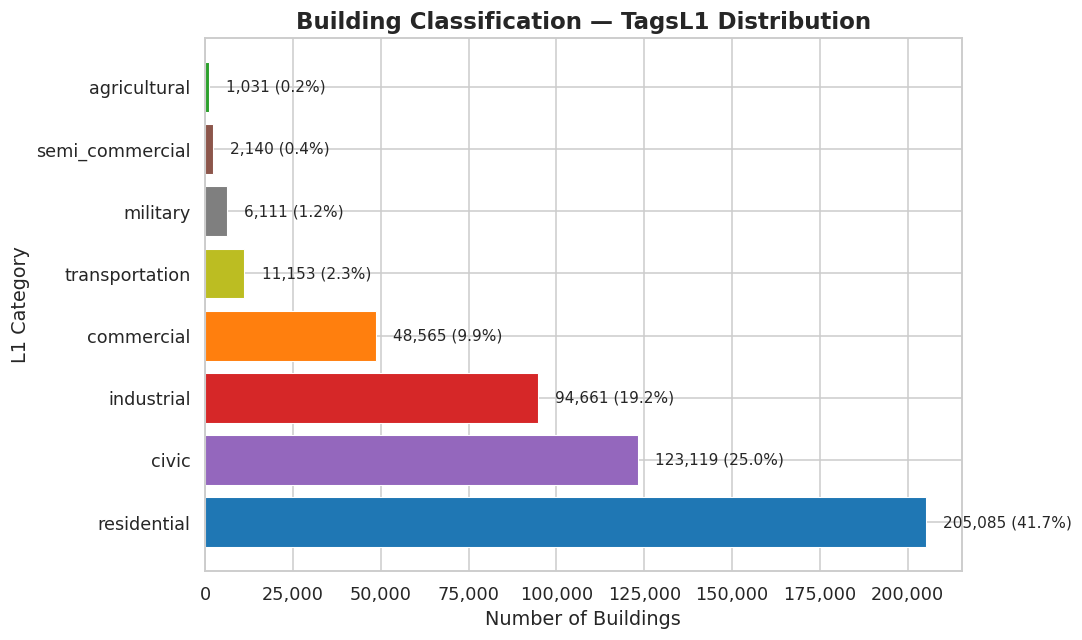

In [162]:
# ── Plot 1: L1 distribution (Horizontal, with counts + percentages) ────────────────
L1_COLORS = {
    'residential': '#1f77b4',
        'commercial': '#ff7f0e',
        'agricultural': '#2ca02c',
        'industrial': '#d62728',
        'civic': '#9467bd',
        'semi_commercial': '#8c564b',
        'transportation':  '#bcbd22',
        'military': '#7f7f7f',
        'filter': '#17becf', # Added just in case
        'Unknown': '#cccccc' # Fallback for unmapped items
}

# Count L1 categories
l1_counts = df['tag_l1'].value_counts()

# Exclude filter
l1_counts = l1_counts[l1_counts.index != 'filter']

# Total buildings (excluding filter)
TOTAL = l1_counts.sum()

colors = [L1_COLORS.get(l, '#bdc3c7') for l in l1_counts.index]

fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bar chart
bars = ax.barh(l1_counts.index, l1_counts.values, color=colors, edgecolor='white', linewidth=0.7)

# Add labels: "count (xx.x%)"
for bar, val in zip(bars, l1_counts.values):
    pct = val / TOTAL * 100
    ax.text(
        bar.get_width() + TOTAL * 0.01,   # slight offset to the right
        bar.get_y() + bar.get_height()/2,
        f'{val:,} ({pct:.1f}%)',
        va='center', ha='left', fontsize=10
    )

ax.set_title('Building Classification — TagsL1 Distribution', fontsize=15, fontweight='bold')
ax.set_xlabel('Number of Buildings')
ax.set_ylabel('L1 Category')

# Format x-axis with thousands separators
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()


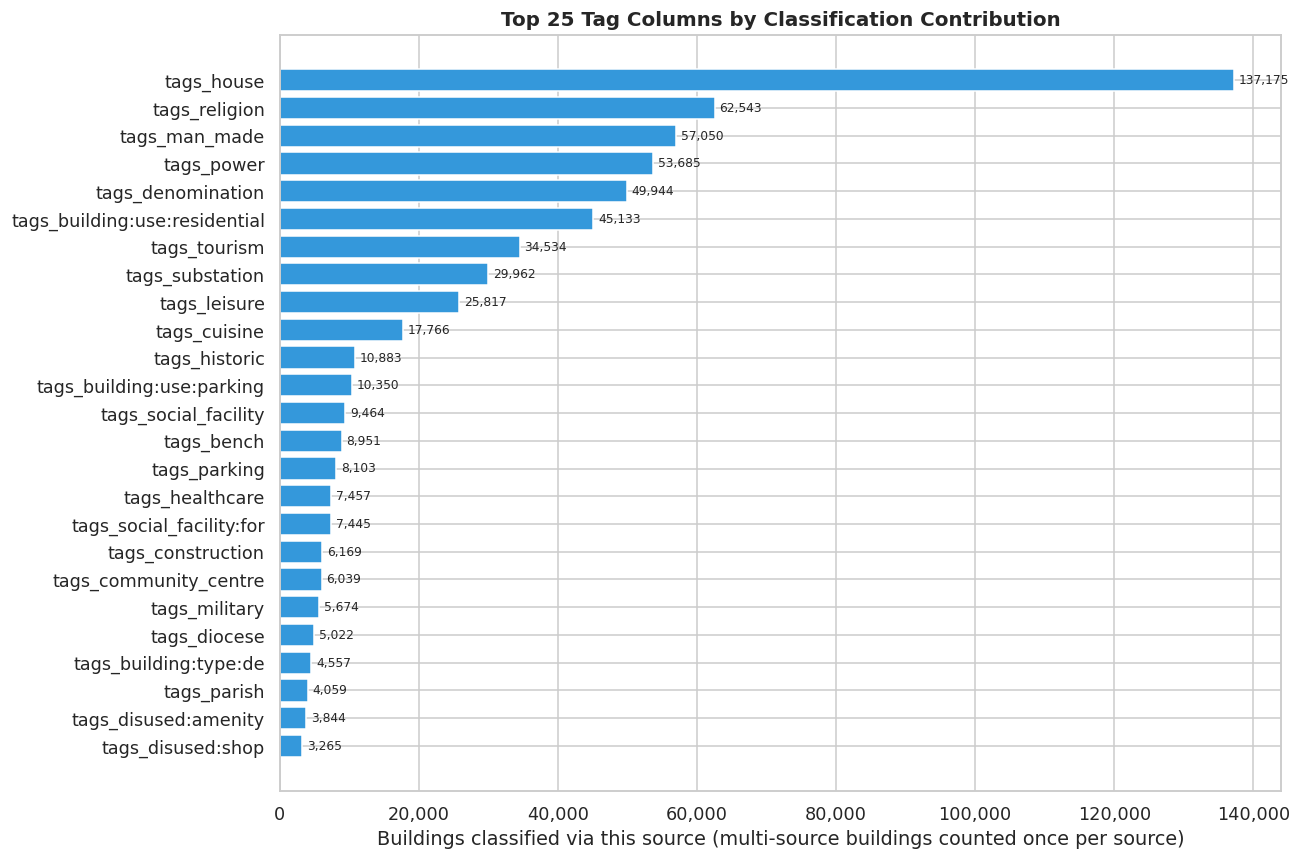

In [163]:
# ── Plot 3: tag source contribution ──────────────────────────────────
# tag_source can be 'a+b+c' for multi-source buildings — explode them
source_series = (df['tag_source']
                 .dropna()
                 .str.split('+')
                 .explode()
                 .str.strip())
src_counts = source_series.value_counts().head(25)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(src_counts.index[::-1], src_counts.values[::-1], color='#3498db', edgecolor='white')
for i, (idx, val) in enumerate(zip(src_counts.index[::-1], src_counts.values[::-1])):
    ax.text(val + src_counts.values.max()*0.005, i,
            f'{val:,}', va='center', fontsize=8)
ax.set_title('Top 25 Tag Columns by Classification Contribution',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Buildings classified via this source (multi-source buildings counted once per source)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('plot3_tag_source_contribution.png', dpi=150, bbox_inches='tight')
plt.show()


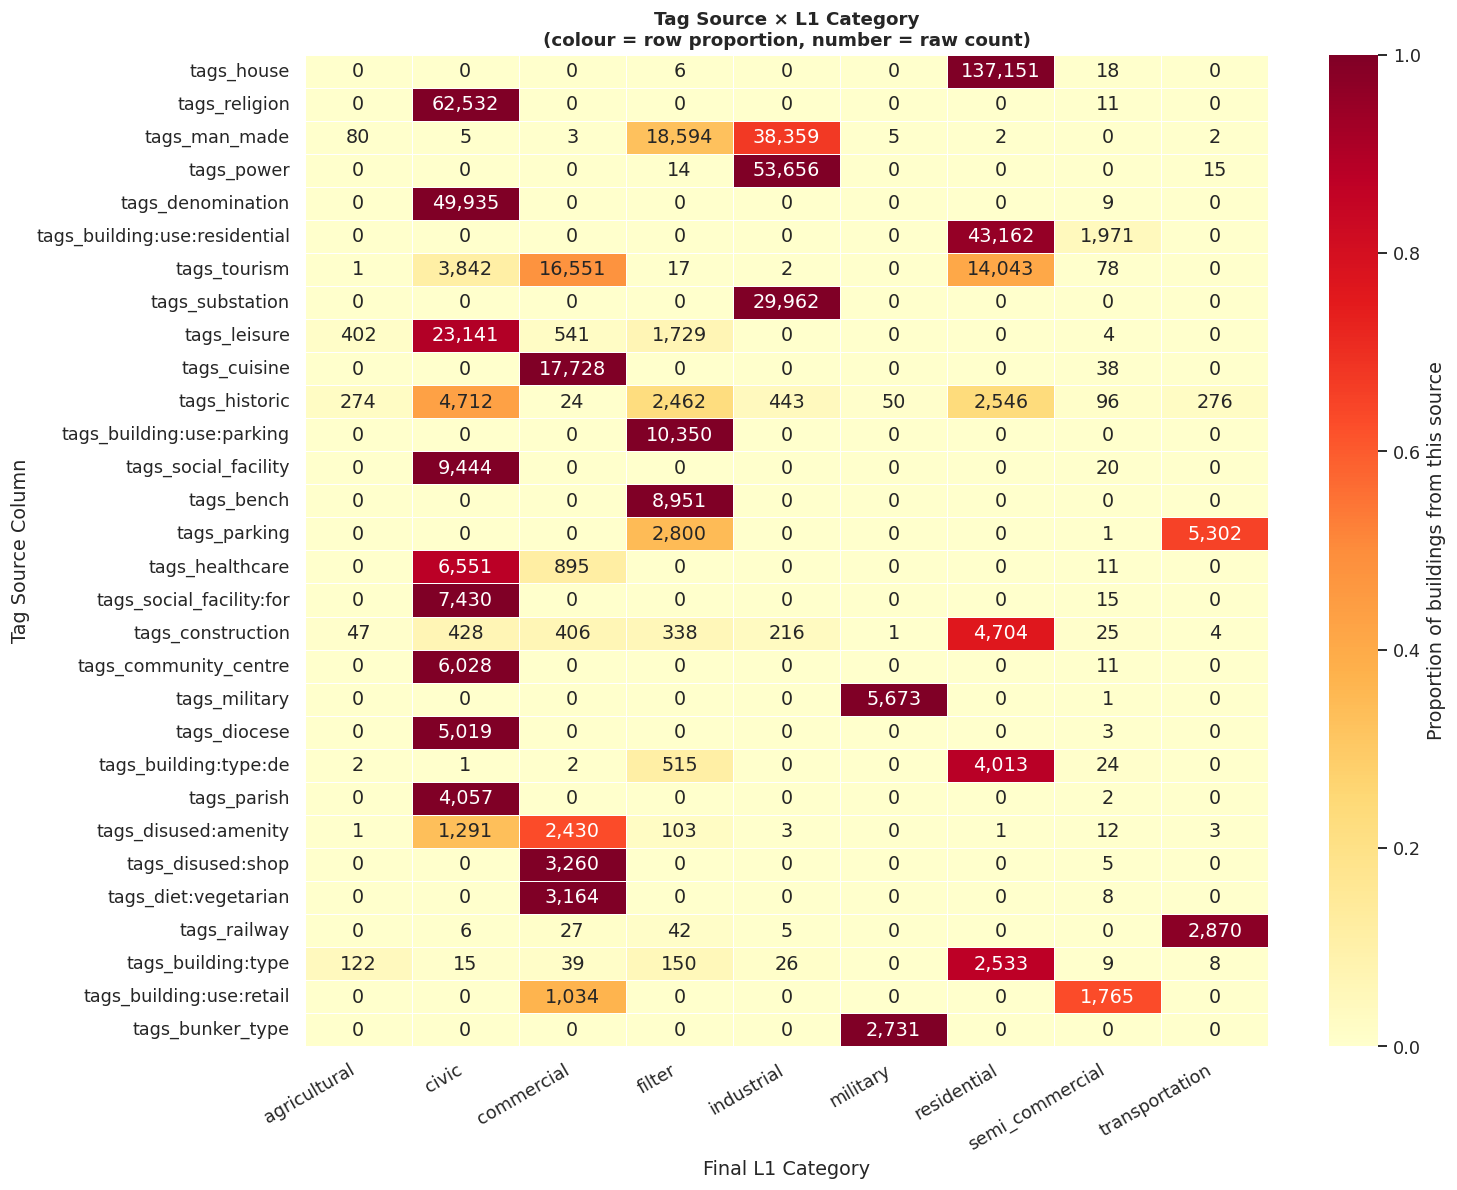

In [164]:
# ── Plot 4: tag × L1 heatmap ─────────────────────────────────────────
# Explode multi-source tag_source so each source gets credited
exploded = (df[df['tag_l1'].notna() & df['tag_source'].notna()]
            [['tag_source', 'tag_l1']]
            .copy())
exploded['tag_source'] = exploded['tag_source'].str.split('+')
exploded = exploded.explode('tag_source').assign(
    tag_source=lambda x: x['tag_source'].str.strip()
)

heat_data = (exploded
             .groupby(['tag_source', 'tag_l1'])
             .size()
             .unstack(fill_value=0))

# Keep top 30 sources by total
heat_data = heat_data.loc[heat_data.sum(axis=1).nlargest(30).index]
heat_norm = heat_data.div(heat_data.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    heat_norm,
    cmap='YlOrRd',
    annot=heat_data,
    fmt=',d',
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'Proportion of buildings from this source'}
)
ax.set_title('Tag Source × L1 Category\n(colour = row proportion, number = raw count)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Tag Source Column')
ax.set_xlabel('Final L1 Category')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('plot4_tag_l1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


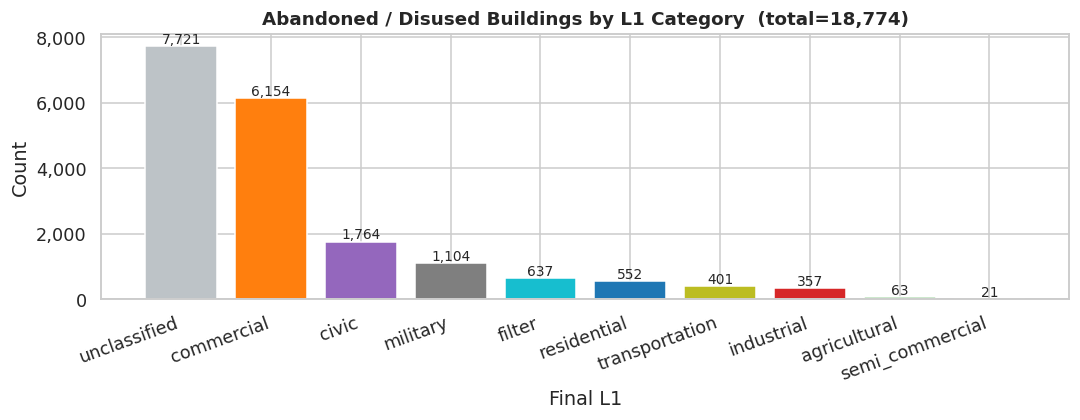

In [167]:
# ── Plot 8: abandoned buildings by L1 ────────────────────────────────
aband_by_l1 = (df[df['is_abandoned']]
               ['tag_l1'].fillna('unclassified').value_counts())

fig, ax = plt.subplots(figsize=(10, 4))
colors_ab = [L1_COLORS.get(l, '#bdc3c7') for l in aband_by_l1.index]
ax.bar(aband_by_l1.index, aband_by_l1.values, color=colors_ab, edgecolor='white')
for i, (idx, val) in enumerate(aband_by_l1.items()):
    ax.text(i, val + aband_by_l1.max()*0.01, f'{val:,}', ha='center', fontsize=9)
ax.set_title(f'Abandoned / Disused Buildings by L1 Category  '
             f'(total={df["is_abandoned"].sum():,})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Final L1')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('plot8_abandoned_by_l1.png', dpi=150, bbox_inches='tight')
plt.show()


In [168]:
# ── Spot-check: sample buildings per L1 for manual review ────────────
SHOW = ['tag_l1', 'tag_l2', 'is_semi_commercial', 'is_abandoned',
        'tag_source', 'tag_used', 'all_candidates']

for l1 in ['residential', 'commercial', 'civic', 'industrial',
           'semi_commercial', 'military', 'agricultural']:
    sub = df[df['tag_l1'] == l1]
    if len(sub) == 0:
        continue
    print(f'\n── {l1.upper()}  (n={len(sub):,}) ──────────────────────────────')
    with pd.option_context('display.max_colwidth', 70):
        display(sub[SHOW].sample(min(5, len(sub))))



── RESIDENTIAL  (n=205,085) ──────────────────────────────


,tag_l1,tag_l2,is_semi_commercial,is_abandoned,tag_source,tag_used,all_candidates
2425405,residential,None,False,False,tags_building:use:residential,yes,"[('tags_building:use:residential', 'residential', None)]"
24705515,residential,SFH,False,False,tags_tourism,chalet,"[('tags_tourism', 'residential', 'SFH')]"
1979866,residential,None,False,False,tags_building:use:residential,yes,"[('tags_building:use:residential', 'residential', None)]"
9905311,residential,None,False,False,tags_house,residential,"[('tags_house', 'residential', None)]"
3249327,residential,TH,False,False,tags_house,terraced,"[('tags_house', 'residential', 'TH')]"



── COMMERCIAL  (n=48,565) ──────────────────────────────


,tag_l1,tag_l2,is_semi_commercial,is_abandoned,tag_source,tag_used,all_candidates
16517007,commercial,accommodation,False,False,tags_tourism,hotel,"[('tags_tourism', 'commercial', 'accommodation')]"
6082283,commercial,accommodation,False,False,tags_cuisine+tags_tourism,guest_house,"[('tags_tourism', 'commercial', 'accommodation'), ('tags_cuisine',..."
4889212,commercial,None,False,False,tags_organic,yes,"[('tags_organic', 'commercial', None)]"
23882809,commercial,accommodation,False,False,tags_cuisine+tags_tourism,hotel,"[('tags_tourism', 'commercial', 'accommodation'), ('tags_cuisine',..."
9535227,commercial,accommodation,False,False,tags_tourism,hotel,"[('tags_tourism', 'commercial', 'accommodation')]"



── CIVIC  (n=123,119) ──────────────────────────────


...

,tag_l1,tag_l2,is_semi_commercial,is_abandoned,tag_source,tag_used,all_candidates
525690,semi_commercial,residential_retail,True,False,tags_building:use:residential+tags_building:use:retail,yes,"[('tags_building:use:retail', 'commercial', 'retail'), ('tags_buil..."
1451465,semi_commercial,residential_retail,True,False,tags_building:use:residential+tags_building:use:retail,yes,"[('tags_building:use:retail', 'commercial', 'retail'), ('tags_buil..."
36411232,semi_commercial,residential_retail,True,False,tags_building:use:residential+tags_building:use:retail,yes,"[('tags_building:use:retail', 'commercial', 'retail'), ('tags_buil..."
4277571,semi_commercial,residential_retail,True,False,tags_building:use:residential+tags_building:use:retail,yes,"[('tags_building:use:retail', 'commercial', 'retail'), ('tags_buil..."
6441631,semi_commercial,residential_food_drink,True,True,tags_disused:amenity+tags_tourism,apartment,"[('tags_tourism', 'residential', 'MFH'), ('tags_disused:amenity', ..."



── MILITARY  (n=6,111) ──────────────────────────────


,tag_l1,tag_l2,is_semi_commercial,is_abandoned,tag_source,tag_used,all_candidates
19039099,military,None,False,False,tags_military,bunker,"[('tags_military', 'military', None)]"
36361711,military,None,False,False,tags_military,bunker,"[('tags_military', 'military', None)]"
36137878,military,bunker,False,False,tags_bunker_type+tags_military,bunker,"[('tags_military', 'military', None), ('tags_bunker_type', 'milita..."
35117990,military,None,False,False,tags_military,bunker,"[('tags_military', 'military', None)]"
37546257,military,bunker,False,True,tags_bunker_type+tags_military,bunker,"[('tags_military', 'military', None), ('tags_bunker_type', 'milita..."



── AGRICULTURAL  (n=1,031) ──────────────────────────────


,tag_l1,tag_l2,is_semi_commercial,is_abandoned,tag_source,tag_used,all_candidates
31841415,agricultural,animal_keeping,False,True,tags_disused:amenity,animal_breeding,"[('tags_disused:amenity', 'agricultural', 'animal_keeping')]"
40350,agricultural,equestrian,False,False,tags_leisure,horse_riding,"[('tags_leisure', 'agricultural', 'equestrian')]"
24887300,agricultural,equestrian,False,False,tags_leisure,horse_riding,"[('tags_leisure', 'agricultural', 'equestrian')]"
18155638,agricultural,equestrian,False,False,tags_leisure,horse_riding,"[('tags_leisure', 'agricultural', 'equestrian')]"
14392212,agricultural,equestrian,False,False,tags_leisure,horse_riding,"[('tags_leisure', 'agricultural', 'equestrian')]"


In [169]:
# rename is_semi_commercial to tag_is_mixed for clarity
df = df.rename(columns={'is_semi_commercial': 'tag_is_mixed'})
df.head()

,addr:city,addr:housenumber,addr:postcode,addr:street,name,building,amenity,building:use,craft,office,...,tags_diet:halal,tags_cuisine,tag_l1,tag_l2,tag_is_mixed,tag_source,tag_used,all_candidates,is_abandoned,n_l1_candidates
0,Weinheim,5,69469,Babostraße,Konferenzhaus Unternehmensgruppe Freudenberg,yes,None,None,None,None,...,None,None,NaN,NaN,False,NaN,NaN,NaN,False,0
1,None,None,None,None,Reithalle,riding_hall,None,None,None,None,...,None,None,NaN,NaN,False,NaN,NaN,NaN,False,0
2,None,None,None,None,None,yes,None,None,None,None,...,None,None,NaN,NaN,False,NaN,NaN,NaN,False,0
3,None,None,None,None,None,yes,None,None,None,None,...,None,None,NaN,NaN,False,NaN,NaN,NaN,False,0
4,None,None,None,None,None,yes,None,None,None,None,...,None,None,NaN,NaN,False,NaN,NaN,NaN,False,0


In [170]:
# ── Save interim (WITH tag columns — for debugging) ───────────────────
OUT_INTERIM = os.path.join(DATA_DIR, 'interim', 'germany_buildings_tags_mapping02d.parquet')
df.to_parquet(OUT_INTERIM, index=False)
print(f'Saved interim (all columns): {OUT_INTERIM}')
print(f'Shape: {df.shape}')

# ── Save processed (WITHOUT tag columns — for downstream use) ─────────
TAG_COLS_TO_DROP = [c for c in df.columns if c.startswith('tags_') or c == 'n_l1_candidates']
KEEP_ALWAYS = [
    'id', 'geometry', 'building',
    'tag_l1', 'tag_l2',
    'is_abandoned', 'tag_is_mixed',
    'tag_source', 'tag_used', 'all_candidates',
]

# Keep any other non-tag columns (area, height, etc.)
other_cols = [c for c in df.columns
              if c not in TAG_COLS_TO_DROP and c not in KEEP_ALWAYS]

final_cols = KEEP_ALWAYS + other_cols
final_cols = [c for c in final_cols if c in df.columns]  # safety

OUT_PROCESSED = os.path.join(DATA_DIR, 'processed', 'germany_buildings_mapped_tags.parquet')
df[final_cols].to_parquet(OUT_PROCESSED, index=False)
print(f'Saved processed (no tag cols): {OUT_PROCESSED}')
print(f'Columns dropped: {len(TAG_COLS_TO_DROP)} tag columns removed.')
print(f'Shape: {df[final_cols].shape}')
print(f'Columns: {final_cols}')

Saved interim (all columns): /fast/home/o-olajuyigbe/osm_project/data/interim/germany_buildings_tags_mapping02d.parquet
Shape: (38802372, 93)
Saved processed (no tag cols): /fast/home/o-olajuyigbe/osm_project/data/processed/germany_buildings_mapped_tags.parquet
Columns dropped: 67 tag columns removed.
Shape: (38802372, 26)
Columns: ['id', 'geometry', 'building', 'tag_l1', 'tag_l2', 'is_abandoned', 'tag_is_mixed', 'tag_source', 'tag_used', 'all_candidates', 'addr:city', 'addr:housenumber', 'addr:postcode', 'addr:street', 'name', 'amenity', 'building:use', 'craft', 'office', 'shop', 'tags', 'building:levels', 'address_tier', 'area_sqm', 'perimeter_m', 'compactness']


In [171]:
len(df[df['building']=='industrial'])

167304

In [172]:
df[(df['building']=='industrial') & (df['tag_l2'].notna())][['id', 'tag_l1', 'tag_l2']].sample(15)

,id,tag_l1,tag_l2
33987921,1024672384,industrial,manufacturing
29190931,718017721,industrial,utilities
2186657,97946381,industrial,utilities
18709397,334305132,industrial,utilities
5272843,154982889,civic,recreation
4019789,131358020,industrial,manufacturing
28678015,685221973,industrial,manufacturing
464548,43719404,industrial,storage
21033501,381582217,industrial,manufacturing
13031454,266115102,industrial,manufacturing
